<center>
    <h1> Analyzing Outcomes with Juvenile Court and Probation </h1>
</center>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# df = pd.read_csv("https://data-openjustice.doj.ca.gov/sites/default/files/dataset/2025-07/JCPSS_2012-2024.csv")
df = pd.read_csv("JCPSS_2012-2024.csv") ### LINK IS VERY SLOW ###
df["RACE_DESC"] = df["RACE_DESC"].str.title()

In [3]:
df.head()

,YEAR,GENDER_DESC,RACE_DESC,AGE_GROUP,ACTION_TYPE_DESC,REFERRAL_TYPE,REFERRAL_SOURCE_DESC,DETENTION_DESC,DEFENSE_REP_DESC,FITNESS_HEARING_ORDERED,FITNESS_HEARING_OUT_DESC,OFFENSE_LEVEL,GROUP_OFFENSE_LEVEL,DISPOSITION_DESC,SUSTAINED_OFFENSE_LEVEL,SUSTAINED_GROUP_OFFENSE_LEVEL,MOST_SERIOUS_SUSTAINED
0,2012,Female,Asian/Pacific Islander,13 and Under,Court,New,Law Enforcement Agency,Detained - Secure Facility,Unknown,N,Fit,Felony,Assault,Informal Probation (654.2 WI),Felony,Assault,*
1,2012,Female,Asian/Pacific Islander,13 and Under,Court,New,Law Enforcement Agency,Detained - Secure Facility,Unknown,N,Fit,Felony,Assault,Wardship,Felony,Assault,*
2,2012,Female,Asian/Pacific Islander,13 and Under,Court,New,Law Enforcement Agency,Not Detained,Public Defender,N,Fit,Felony,Assault,Wardship,Felony,Assault,*
3,2012,Female,Asian/Pacific Islander,14 - 15,Court,New,Law Enforcement Agency,Detained - Secure Facility,Public Defender,N,Fit,Felony,Assault,Wardship,Felony,Assault,*
4,2012,Female,Asian/Pacific Islander,14 - 15,Court,New,Law Enforcement Agency,Detained - Secure Facility,Public Defender,N,Fit,Felony,Assault,Deferred Entry of Judgement,Felony,Assault,*


In [4]:
felony_data = pd.DataFrame()

def annualFelony(year):
    global felony_data
    print(f"=== EXPLORING {year} ===\n")
    data = df[(df["YEAR"] == year) & (df["OFFENSE_LEVEL"] == "Felony")]

    counts = data.groupby("RACE_DESC").count()
    total = counts["YEAR"].sum()

    counts = counts[["YEAR"]].sort_values(by="YEAR")
    counts.columns = ["COUNT OF FELONIES"]

    per = (counts / total) * 100
    per.columns = ["% OF FELONIES"]

    result = pd.concat([counts, per], axis=1)
    display(result)
    result["YEAR"] = year

    if "YEAR" not in felony_data.columns or year not in felony_data["YEAR"].unique():
        felony_data = pd.concat([felony_data, result.reset_index()], ignore_index=True)

    my_cmap = plt.get_cmap("Blues")
    plt.barh(y=counts.index, width=(counts["COUNT OF FELONIES"] / total)*100, color=my_cmap(sorted([255, 225, 175, 100, 70, 50])))
    plt.title("Source: data-openjustice.doj.ca.gov")
    plt.ylabel("Percentage %")
    plt.xlabel(f"Racial Percentages of Felonies Amongst Minors (US {year})")
    if year >= 2020:
        plt.show()
    plt.savefig(f"figs/felony_{year}.png")
        

=== EXPLORING 2012 ===



,COUNT OF FELONIES,% OF FELONIES
RACE_DESC,,
Asian/Pacific Islander,1048,2.504601
Other,1266,3.025596
White,7904,18.889659
Black,9397,22.457759
Hispanic,22228,53.122386


=== EXPLORING 2013 ===



,COUNT OF FELONIES,% OF FELONIES
RACE_DESC,,
Asian/Pacific Islander,928,2.476384
Other,1005,2.681859
White,6757,18.031168
Black,8830,23.563004
Hispanic,19954,53.247585


=== EXPLORING 2014 ===



...

,COUNT OF FELONIES,% OF FELONIES
RACE_DESC,,
Asian/Pacific Islander,509,2.160900
Other,876,3.718956
White,3597,15.270643
Black,6171,26.198259
Hispanic,12402,52.651242


=== EXPLORING 2019 ===



,COUNT OF FELONIES,% OF FELONIES
RACE_DESC,,
Asian/Pacific Islander,472,2.105827
Other,933,4.162577
White,3325,14.834478
Black,5795,25.854377
Hispanic,11889,53.042741


=== EXPLORING 2020 ===



,COUNT OF FELONIES,% OF FELONIES
RACE_DESC,,
Asian/Pacific Islander,373,2.083101
Other,782,4.367251
White,2588,14.453256
Black,4507,25.170334
Hispanic,9656,53.926058


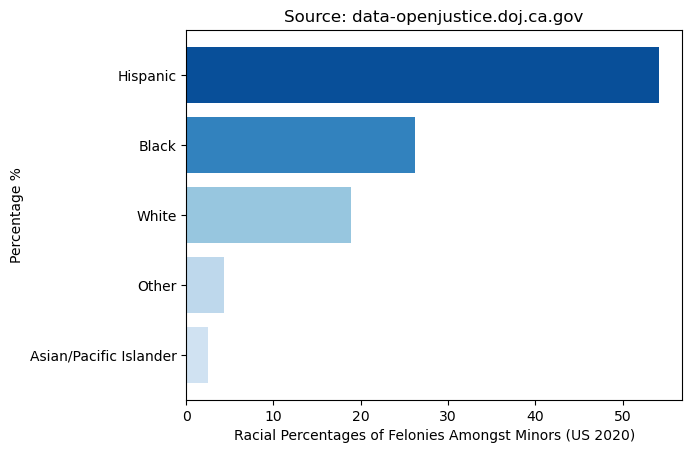

=== EXPLORING 2021 ===



,COUNT OF FELONIES,% OF FELONIES
RACE_DESC,,
Asian/Pacific Islander,310,2.133370
Other,661,4.548895
White,2159,14.857890
Black,3608,24.829674
Hispanic,7793,53.630170


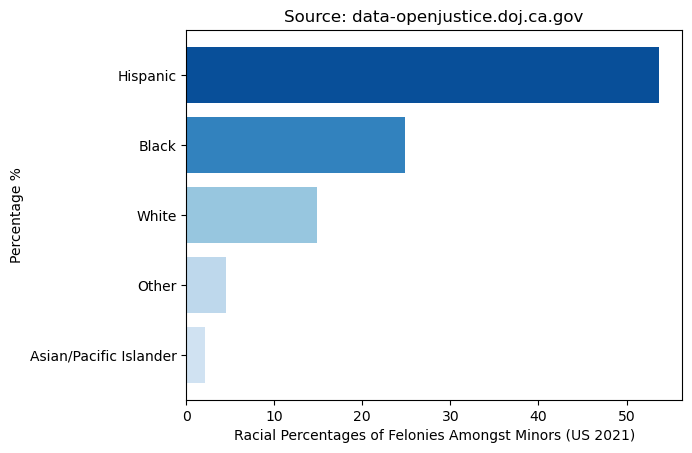

=== EXPLORING 2022 ===



,COUNT OF FELONIES,% OF FELONIES
RACE_DESC,,
Asian/Pacific Islander,405,2.526828
Other,753,4.698028
White,2333,14.555777
Black,3750,23.396556
Hispanic,8787,54.822810


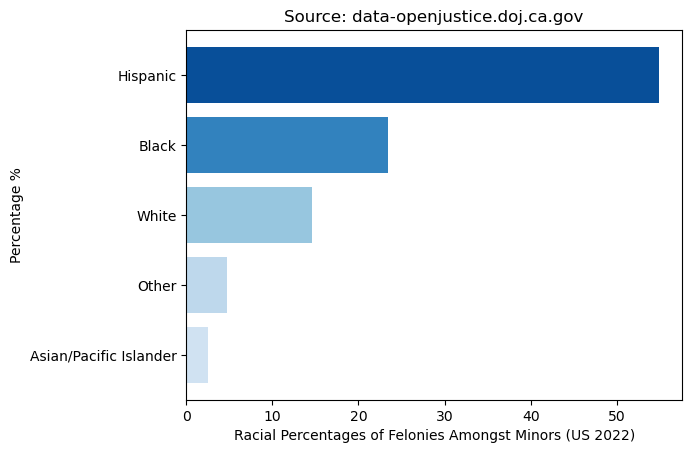

=== EXPLORING 2023 ===



,COUNT OF FELONIES,% OF FELONIES
RACE_DESC,,
Asian/Pacific Islander,436,2.172072
Other,985,4.907089
White,2853,14.213122
Black,4521,22.522792
Hispanic,11278,56.184925


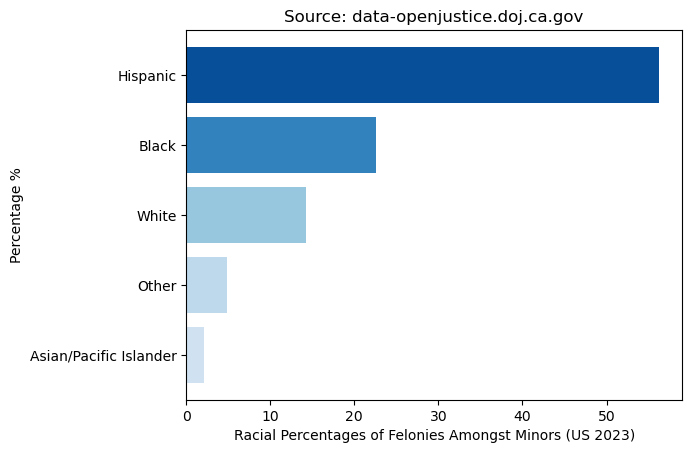

=== EXPLORING 2024 ===



,COUNT OF FELONIES,% OF FELONIES
RACE_DESC,,
Asian/Pacific Islander,500,2.280502
Other,1237,5.641961
White,2903,13.240593
Black,4919,22.435576
Hispanic,12366,56.401368


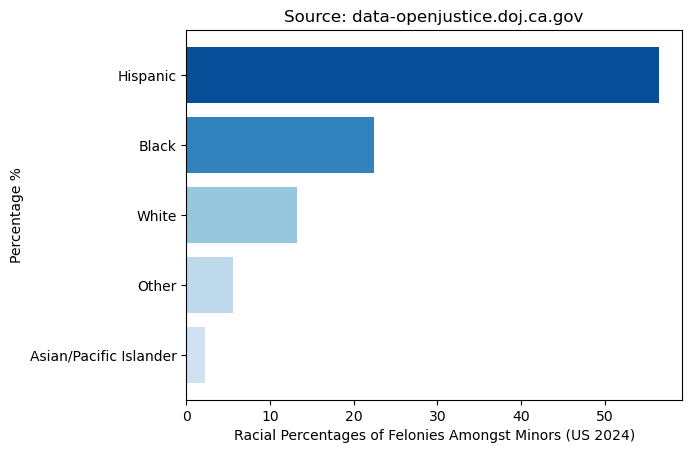

<Figure size 640x480 with 0 Axes>

In [5]:
for year in range(2012, 2025):
    annualFelony(year)

felony_data.to_csv("data/felony_data.csv")

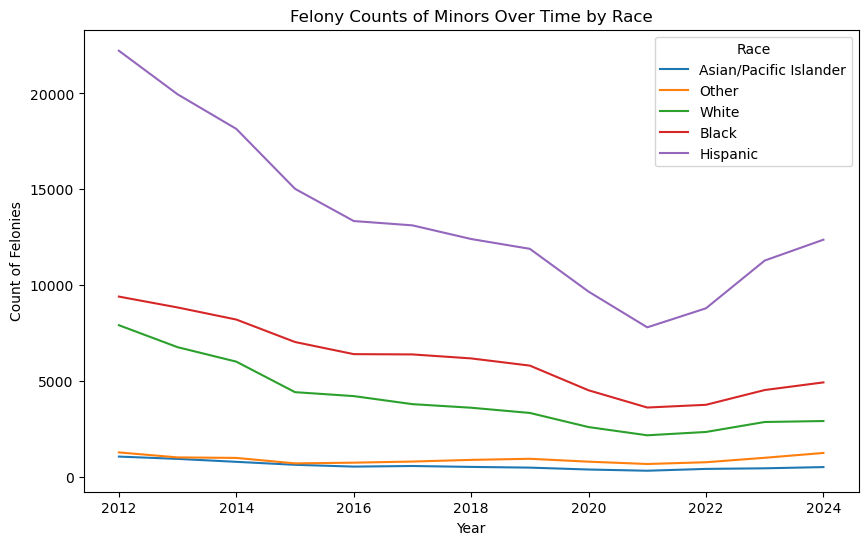

In [6]:
plt.figure(figsize=(10, 6)) # made it widerrrr
for race in felony_data["RACE_DESC"].unique():
    race_df = felony_data[felony_data["RACE_DESC"] == race]
    plt.plot(
        race_df["YEAR"],
        race_df["COUNT OF FELONIES"],
        label=race
    )

plt.title("Felony Counts of Minors Over Time by Race")
plt.xlabel("Year")
plt.ylabel("Count of Felonies")
plt.legend(title="Race")

plt.savefig("figs/felonies_over_time.png")


In [7]:
misdem_data = pd.DataFrame()

def annualMisdem(year):
    global misdem_data
    
    print(f"=== EXPLORING {year} ===\n")
    data = df[(df["YEAR"] == year) & (df["OFFENSE_LEVEL"] == "Misdemeanor")]

    counts = data.groupby("RACE_DESC").count()
    total = counts["YEAR"].sum()

    counts = counts[["YEAR"]].sort_values(by="YEAR")
    counts.columns = ["COUNT OF MISDEMEANORS"]
    # display(counts)

    per = (counts / total) * 100
    per.columns = ["% OF MISDEMEANORS"]
    # display(per)

    result = pd.concat([counts, per], axis=1)
    display(result)
    result["YEAR"] = year

    if "YEAR" not in misdem_data.columns or year not in misdem_data["YEAR"].unique():
        misdem_data = pd.concat([misdem_data, result.reset_index()], ignore_index=True)

    my_cmap = plt.get_cmap("Oranges")
    plt.barh(y=counts.index, width=(counts["COUNT OF MISDEMEANORS"] / total)*100, color=my_cmap(sorted([255, 225, 175, 100, 70, 50])))
    plt.title("Source: data-openjustice.doj.ca.gov")
    plt.ylabel("Percentage %")
    plt.xlabel(f"Racial Percentages of Misdemeanors Amongst Minors (US {year})")
    if year >= 2020:
        plt.show()
    plt.savefig(f"figs/misdemeanor_{year}.png")

=== EXPLORING 2012 ===



,COUNT OF MISDEMEANORS,% OF MISDEMEANORS
RACE_DESC,,
Asian/Pacific Islander,1624,2.421351
Other,2438,3.635008
Black,10062,15.002236
White,17463,26.036976
Hispanic,35483,52.904428


=== EXPLORING 2013 ===



,COUNT OF MISDEMEANORS,% OF MISDEMEANORS
RACE_DESC,,
Asian/Pacific Islander,1280,2.139395
Other,2020,3.376233
Black,9468,15.824837
White,14752,24.656527
Hispanic,32310,54.003009


=== EXPLORING 2014 ===



...

,COUNT OF MISDEMEANORS,% OF MISDEMEANORS
RACE_DESC,,
Asian/Pacific Islander,718,2.200564
Other,1538,4.713743
Black,5223,16.007723
White,7219,22.125169
Hispanic,17930,54.952801


=== EXPLORING 2019 ===



,COUNT OF MISDEMEANORS,% OF MISDEMEANORS
RACE_DESC,,
Asian/Pacific Islander,614,2.020667
Other,1680,5.528862
Black,4776,15.717765
White,6768,22.273415
Hispanic,16548,54.459290


=== EXPLORING 2020 ===



,COUNT OF MISDEMEANORS,% OF MISDEMEANORS
RACE_DESC,,
Asian/Pacific Islander,427,2.022930
Other,1236,5.855600
Black,3156,14.951677
White,4689,22.214326
Hispanic,11600,54.955467


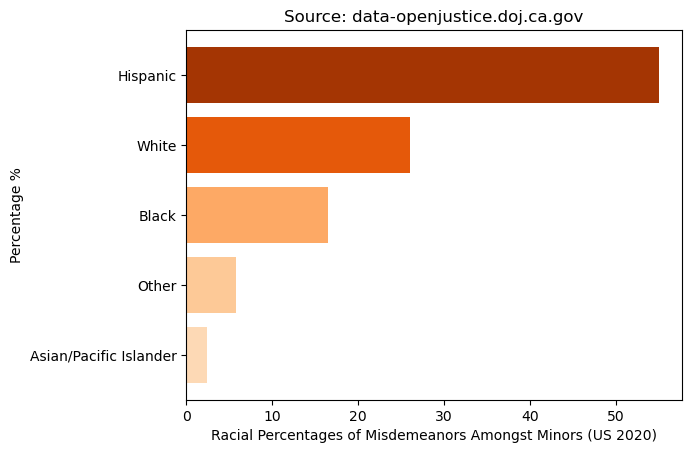

=== EXPLORING 2021 ===



,COUNT OF MISDEMEANORS,% OF MISDEMEANORS
RACE_DESC,,
Asian/Pacific Islander,263,1.831604
Other,941,6.553381
Black,1997,13.907654
White,3259,22.696567
Hispanic,7899,55.010795


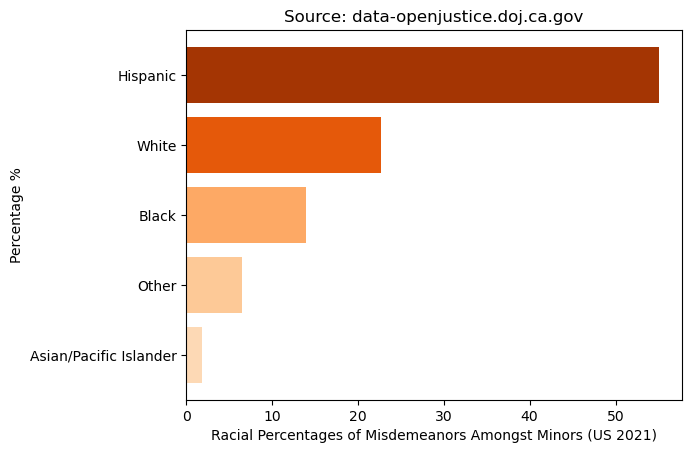

=== EXPLORING 2022 ===



,COUNT OF MISDEMEANORS,% OF MISDEMEANORS
RACE_DESC,,
Asian/Pacific Islander,350,1.900831
Other,1163,6.316190
Black,2353,12.779015
White,4058,22.038777
Hispanic,10489,56.965188


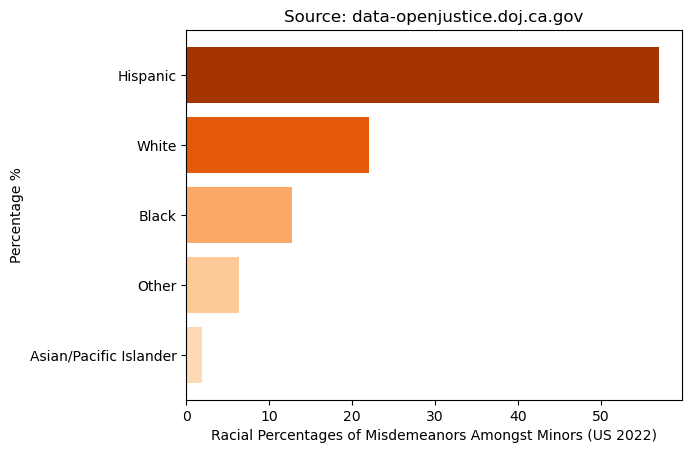

=== EXPLORING 2023 ===



,COUNT OF MISDEMEANORS,% OF MISDEMEANORS
RACE_DESC,,
Asian/Pacific Islander,413,2.027790
Other,1286,6.314136
Black,2686,13.188000
White,4025,19.762361
Hispanic,11957,58.707713


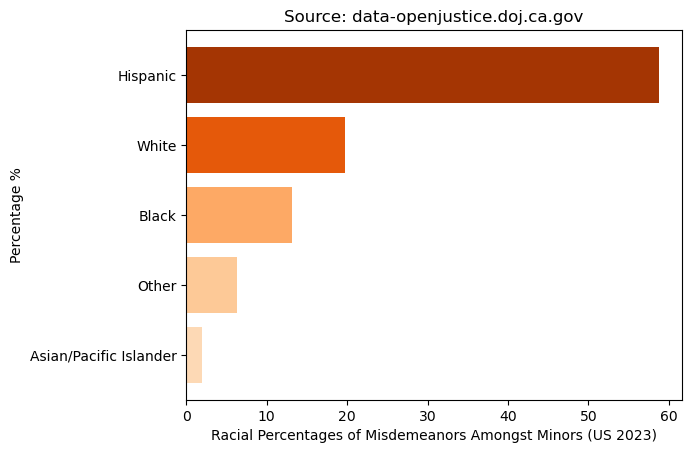

=== EXPLORING 2024 ===



,COUNT OF MISDEMEANORS,% OF MISDEMEANORS
RACE_DESC,,
Asian/Pacific Islander,324,1.639344
Other,1381,6.987452
Black,2928,14.814815
White,3928,19.874519
Hispanic,11203,56.683870


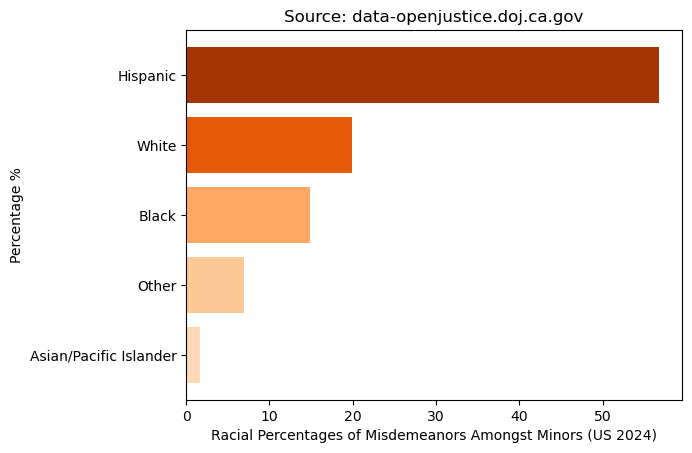

<Figure size 640x480 with 0 Axes>

In [8]:
for year in range(2012, 2025):
    annualMisdem(year)

misdem_data.to_csv("data/misdem_data.csv")

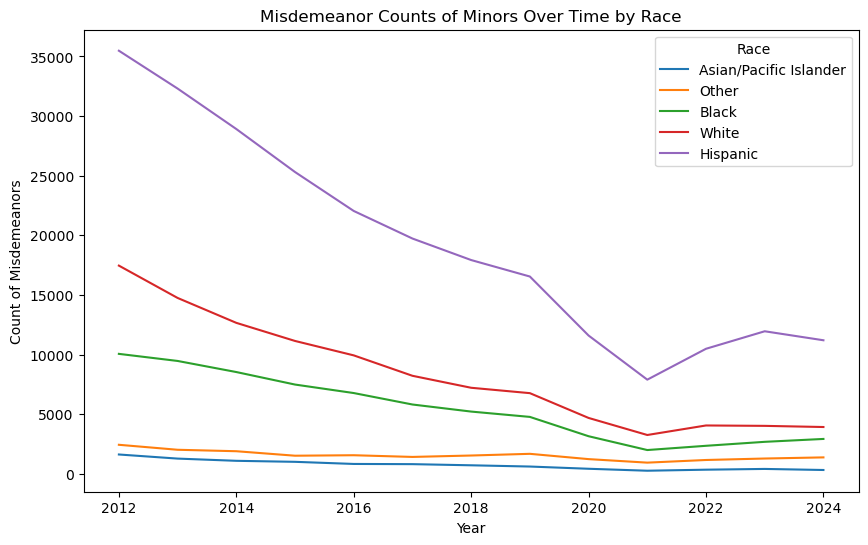

In [9]:
plt.figure(figsize=(10, 6)) # made it widerrrr
for race in misdem_data["RACE_DESC"].unique():
    race_df = misdem_data[misdem_data["RACE_DESC"] == race]
    plt.plot(
        race_df["YEAR"],
        race_df["COUNT OF MISDEMEANORS"],
        label=race
    )

plt.title("Misdemeanor Counts of Minors Over Time by Race")
plt.xlabel("Year")
plt.ylabel("Count of Misdemeanors")
plt.legend(title="Race")

plt.savefig("figs/misdemeanor_over_time.png")